# Identify CSTR-separator (4x4) SS using N4SID (closed-loop HPO trial 91)


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
import numpy as np
import sys
import joblib
from sklearn.preprocessing import StandardScaler

from sippy_unipi import system_identification
from sippy_unipi import functionsetSIM as fsetSIM

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

import models
%load_ext autoreload
%autoreload 2


Models imported succesfully


## Loading the identification dataset


In [2]:
# Plant used to generate ../data/cstr_separator_ident.npz (square 4x4 variant)
CSTR = models.CSTRSeparator4x4()


In [3]:
# Load pre-generated CSTR-separator identification data (square 4x4 variant)
# Y: [T1, T2, T3, xB3], U: [Q1, Q2, Q3, F10] (F20, Fr fixed; yield-paired steps, 180 s holds)
data = np.load("../data/cstr_separator_ident.npz", allow_pickle=True)
sim = {"Y": np.array(data["Y"], dtype=float), "U": np.array(data["U"], dtype=float)}
print("Loaded", data.files)
print("Y", sim["Y"].shape, list(data["y_names"]))
print("U", sim["U"].shape, list(data["u_names"]))
print("Ts =", float(data["Ts"]), "step_time =", int(data["step_time"]), "no_steps =", int(data["no_steps"]))


Loaded ['Y', 'Y_clean', 'U', 'X', 'U_plant', 'Ts', 'step_time', 'no_steps', 'y_names', 'u_names', 'x0', 'u_nom', 'mv_constraints', 'noise_frac', 'noise_sigma', 'noise_seed', 'n_train_noise']
Y (18000, 4) [np.str_('T1'), np.str_('T2'), np.str_('T3'), np.str_('xB3')]
U (18000, 4) [np.str_('Q1'), np.str_('Q2'), np.str_('Q3'), np.str_('F10')]
Ts = 1.0 step_time = 180 no_steps = 100


In [4]:
# Measurement noise is already in Y (1% of train-range, stored in the npz).
if "noise_sigma" in data.files:
    print("Stored measurement noise (already in Y):")
    for name, s in zip(data["y_names"], np.array(data["noise_sigma"], dtype=float)):
        print(f"  {name}: sigma={s:.4g}")
    print("noise_frac =", float(data["noise_frac"]), "seed =", int(data["noise_seed"]))


Stored measurement noise (already in Y):
  T1: sigma=0.4866
  T2: sigma=0.5267
  T3: sigma=0.6101
  xB3: sigma=0.003435
noise_frac = 0.01 seed = 42


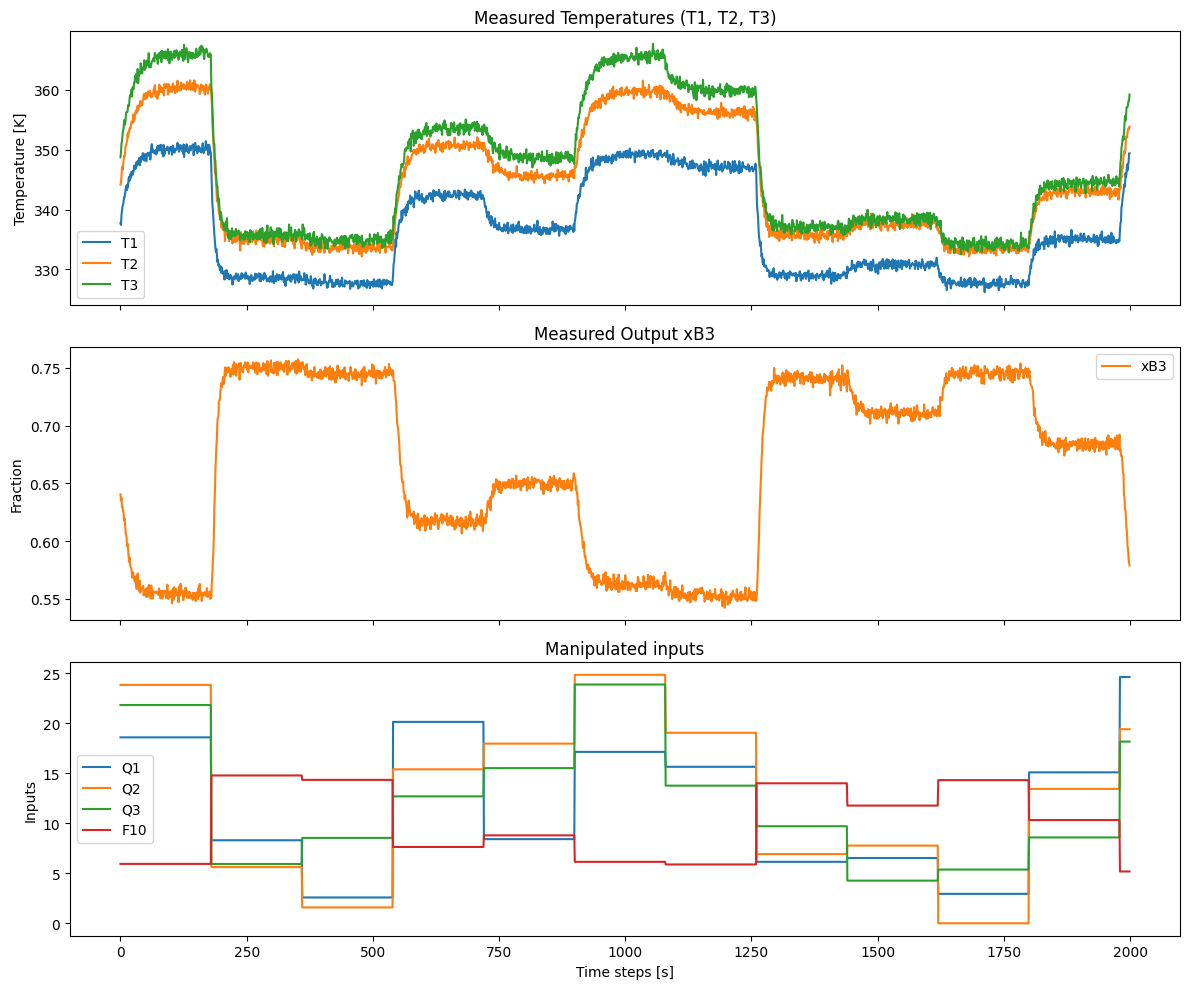

In [5]:
part = 2000
y_names = list(data["y_names"])
u_names = list(data["u_names"])  # ["Q1", "Q2", "Q3", "F10"]; F20, Fr fixed

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot T1, T2, T3 together
for i, name in enumerate(y_names[:-1]):  # T1, T2, T3
    axes[0].plot(sim["Y"][:part, i], label=name)
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Measured Temperatures (T1, T2, T3)")
axes[0].legend()

# Plot xB3 separately
axes[1].plot(sim["Y"][:part, 3], label="xB3", color="tab:orange")
axes[1].set_ylabel("Fraction")
axes[1].set_title("Measured Output xB3")
axes[1].legend()

# Plot inputs
for i, name in enumerate(u_names):
    axes[2].plot(sim["U"][:part, i], label=name)
axes[2].set_xlabel("Time steps [s]")
axes[2].set_ylabel("Inputs")
axes[2].set_title("Manipulated inputs")
axes[2].legend()

plt.tight_layout()
plt.show()


In [6]:
# Fit scalers on the training split (same convention as Koopman notebooks)
n_train, n_dev = 12960, 2880
train_raw = {key: value[:n_train] for key, value in sim.items()}
dev_raw = {key: value[n_train:n_train + n_dev] for key, value in sim.items()}
test_raw = {key: value[n_train + n_dev:] for key, value in sim.items()}

scaler = StandardScaler()
scaler.fit(train_raw["Y"])
joblib.dump(scaler, "../data/scaler_cstr_separator.pkl")

scalerU = StandardScaler()
scalerU.fit(train_raw["U"])
joblib.dump(scalerU, "../data/scalerU_cstr_separator.pkl")


['../data/scalerU_cstr_separator.pkl']

In [7]:
train_sim = {
    "Y": scaler.transform(train_raw["Y"]),
    "U": scalerU.transform(train_raw["U"]),
}
dev_sim = {
    "Y": scaler.transform(dev_raw["Y"]),
    "U": scalerU.transform(dev_raw["U"]),
}
test_sim = {
    "Y": scaler.transform(test_raw["Y"]),
    "U": scalerU.transform(test_raw["U"]),
}
print("train", train_sim["Y"].shape, "dev", dev_sim["Y"].shape, "test", test_sim["Y"].shape)


train (12960, 4) dev (2880, 4) test (2160, 4)


## Identification using PARSIM-K


In [8]:
# SIPPY wants (n_signals, N). It auto-transposes, but be explicit.
y_tot = train_sim["Y"].T.copy()
U = train_sim["U"].T.copy()
print("y_tot", y_tot.shape, "U", U.shape)


y_tot (4, 12960) U (4, 12960)


In [9]:
# Closed-loop HPO trial 91 (N4SID n=16, SS_f=21, MeanVal, A_stability).
# Use the same SS_Model._identify path as hpo_sippy_cl.py so SS_A_stability is forwarded.
from hpo_sippy_cl import SippyParams, identify_sippy, patch_sippy_vn_mat

patch_sippy_vn_mat()
params = SippyParams(
    method="N4SID",
    n=16,
    f_extra=5,
    centering="MeanVal",
    SS_A_stability=True,
)
sys_id = identify_sippy(y_tot.copy(), U.copy(), params)
print(
    f"trial 91 N4SID  n={sys_id.A.shape[0]}  SS_f={params.SS_f}  "
    f"centering={params.centering}  rho={np.max(np.abs(np.linalg.eigvals(sys_id.A))):.5f}"
)


order      test MAE      test MSE      rho(A)


    4      0.779261       3.06368     0.99093


    5      0.397079      0.272444     0.98903


    6      0.292824      0.126373     0.98954


    7      0.300046      0.130055     0.98952


...

   16      0.297591      0.128221     0.98899


   17      0.297452      0.128135     0.98904


   18      0.297419      0.128115     0.98906


   19      0.297575      0.128198     0.98905


   20      0.297509      0.128119     0.98904
best test MAE: order 6  MAE=0.292824


In [10]:
# Matrices already identified in the previous cell (trial 91 settings).
ident = sys_id

Warning! The horizon must be larger than the model order, max_order setted as f


/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


In [11]:
sys_id.A


array([[ 9.49923390e-01, -5.44750261e-02, -1.27552825e-03,
         1.75278229e-02, -1.29939195e-03,  3.41099395e-03],
       [-1.52070941e-02,  9.74598386e-01, -2.48169511e-02,
         3.62792764e-02, -7.34507692e-03,  1.10852122e-03],
       [-3.81332133e-03,  2.44670848e-03,  9.74957335e-01,
         6.03099734e-03, -3.31474264e-02, -5.10612435e-02],
       [-3.87115736e-02, -4.48479983e-02, -2.92839804e-02,
         9.11045450e-01, -3.37270012e-02,  3.80996178e-02],
       [ 2.66614497e-02,  2.99570191e-02,  1.31834837e-02,
         3.23966639e-02,  9.82607589e-01, -6.63475005e-02],
       [ 6.56353632e-02,  7.39289147e-02,  2.42144442e-02,
         6.74927481e-02,  8.70594711e-04,  8.37666758e-01]])

In [12]:
append = "_cstr_separator_parsimK"
np.save("../data/A" + append + ".npy", sys_id.A)
np.save("../data/B" + append + ".npy", sys_id.B)
np.save("../data/C" + append + ".npy", sys_id.C)
np.save("../data/D" + append + ".npy", sys_id.D)
# Control notebooks / weight_sweep load the sippy_hpo stem.
for stem in ("_cstr_separator_sippy_hpo",):
    np.save("../data/A" + stem + ".npy", sys_id.A)
    np.save("../data/B" + stem + ".npy", sys_id.B)
    np.save("../data/C" + stem + ".npy", sys_id.C)
    np.save("../data/D" + stem + ".npy", sys_id.D)


In [13]:
xid, yid = fsetSIM.SS_lsim_process_form(
    sys_id.A, sys_id.B, sys_id.C, sys_id.D,
    test_sim["U"].T,
    np.linalg.pinv(sys_id.C) @ test_sim["Y"][0].reshape(-1, 1),
)


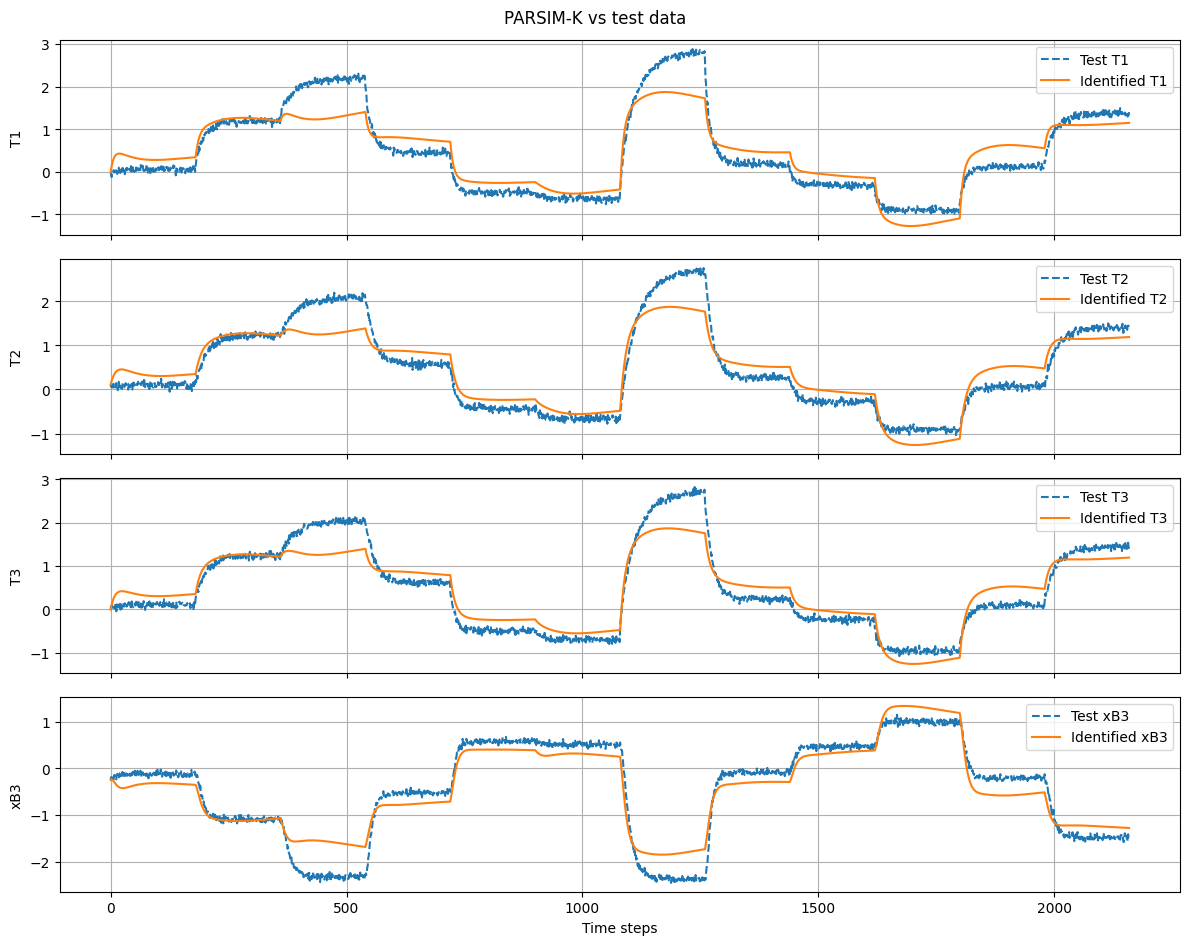

Test MAE per output: [0.32870917 0.29141666 0.2830878  0.26808371]
Sum of MAE: 1.1712973326314797


In [14]:
y_names = ["T1", "T2", "T3", "xB3"]
n_y = test_sim["Y"].shape[1]
fig, axes = plt.subplots(n_y, 1, figsize=(12, 2.4 * n_y), sharex=True)
if n_y == 1:
    axes = [axes]
for i, name in enumerate(y_names[:n_y]):
    axes[i].plot(test_sim["Y"][:, i], label=f"Test {name}", linestyle="--")
    axes[i].plot(yid[i, :], label=f"Identified {name}")
    axes[i].set_ylabel(name)
    axes[i].legend()
    axes[i].grid()
axes[-1].set_xlabel("Time steps")
fig.suptitle("PARSIM-K vs test data")
plt.tight_layout()
plt.show()

test_mae = np.mean(np.abs(test_sim["Y"].T - yid), axis=1)
print("Test MAE per output:", test_mae)
print("Sum of MAE:", np.sum(test_mae))


In [15]:
xid, yid = fsetSIM.SS_lsim_process_form(
    sys_id.A, sys_id.B, sys_id.C, sys_id.D,
    train_sim["U"].T,
    np.linalg.pinv(sys_id.C) @ train_sim["Y"][0].reshape(-1, 1),
)


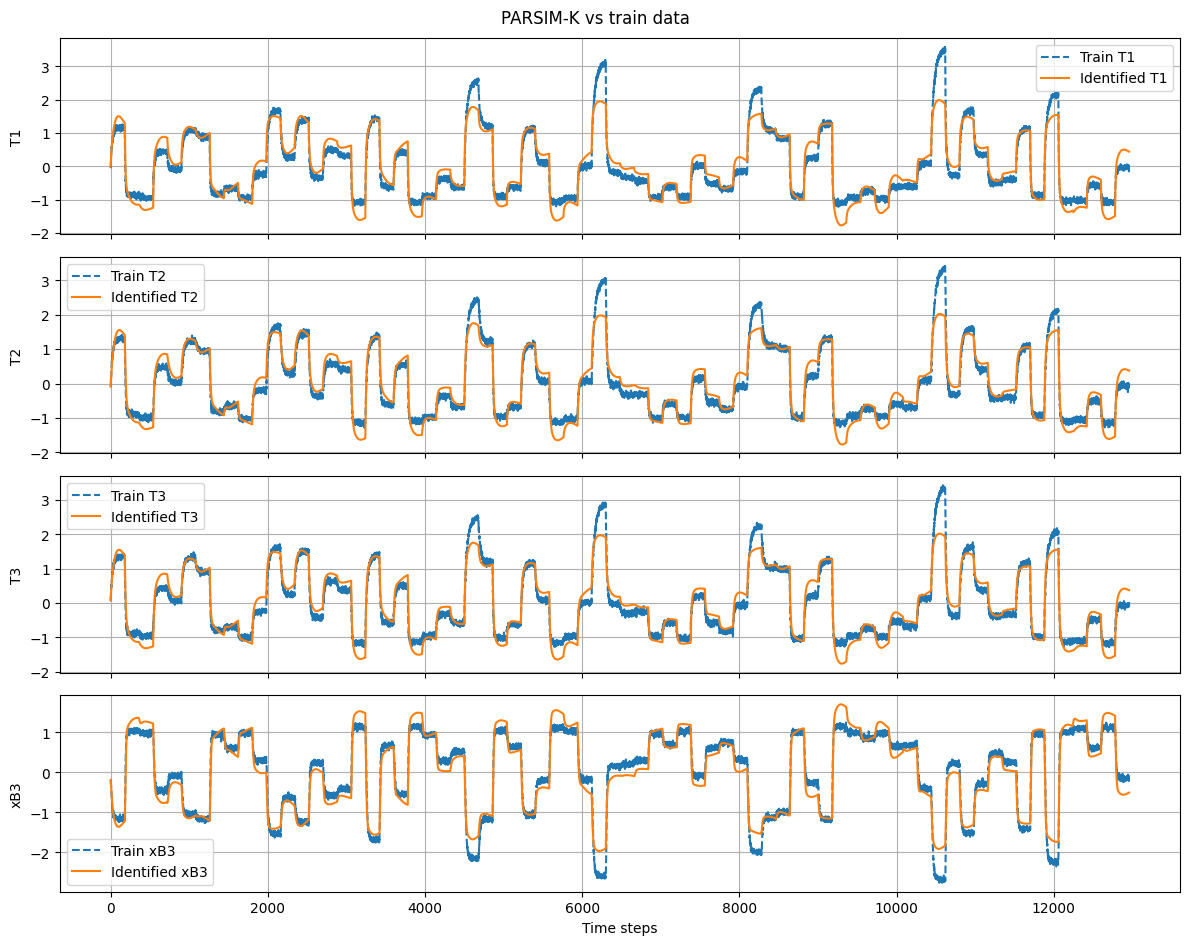

In [16]:
y_names = ["T1", "T2", "T3", "xB3"]
n_y = train_sim["Y"].shape[1]
fig, axes = plt.subplots(n_y, 1, figsize=(12, 2.4 * n_y), sharex=True)
if n_y == 1:
    axes = [axes]
for i, name in enumerate(y_names[:n_y]):
    axes[i].plot(train_sim["Y"][:, i], label=f"Train {name}", linestyle="--")
    axes[i].plot(yid[i, :], label=f"Identified {name}")
    axes[i].set_ylabel(name)
    axes[i].legend()
    axes[i].grid()
axes[-1].set_xlabel("Time steps")
fig.suptitle("PARSIM-K vs train data")
plt.tight_layout()
plt.show()
